In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [2]:
dfd = pd.read_csv(r"C:\Users\rishy\Desktop\New folder\infosys\day.csv")
dfh = pd.read_csv(r"C:\Users\rishy\Downloads\ml\hour.csv")

In [3]:

columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
dfd.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')

columns_to_drop_hour = ['dteday', 'casual', 'registered', 'yr', 'instant']
dfh = dfh.drop(columns=columns_to_drop_hour, errors='ignore')
dfh = dfh.drop_duplicates()

numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

def remove_outliers_corrected(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
      
        df = df[(df[col] >= lower) & (df[col] <= upper)].copy() 
    return df

dfd = remove_outliers_corrected(dfd, numeric_cols)
dfh = remove_outliers_corrected(dfh, numeric_cols)

print("Preprocessing and Outlier Removal Completed.")



Preprocessing and Outlier Removal Completed.


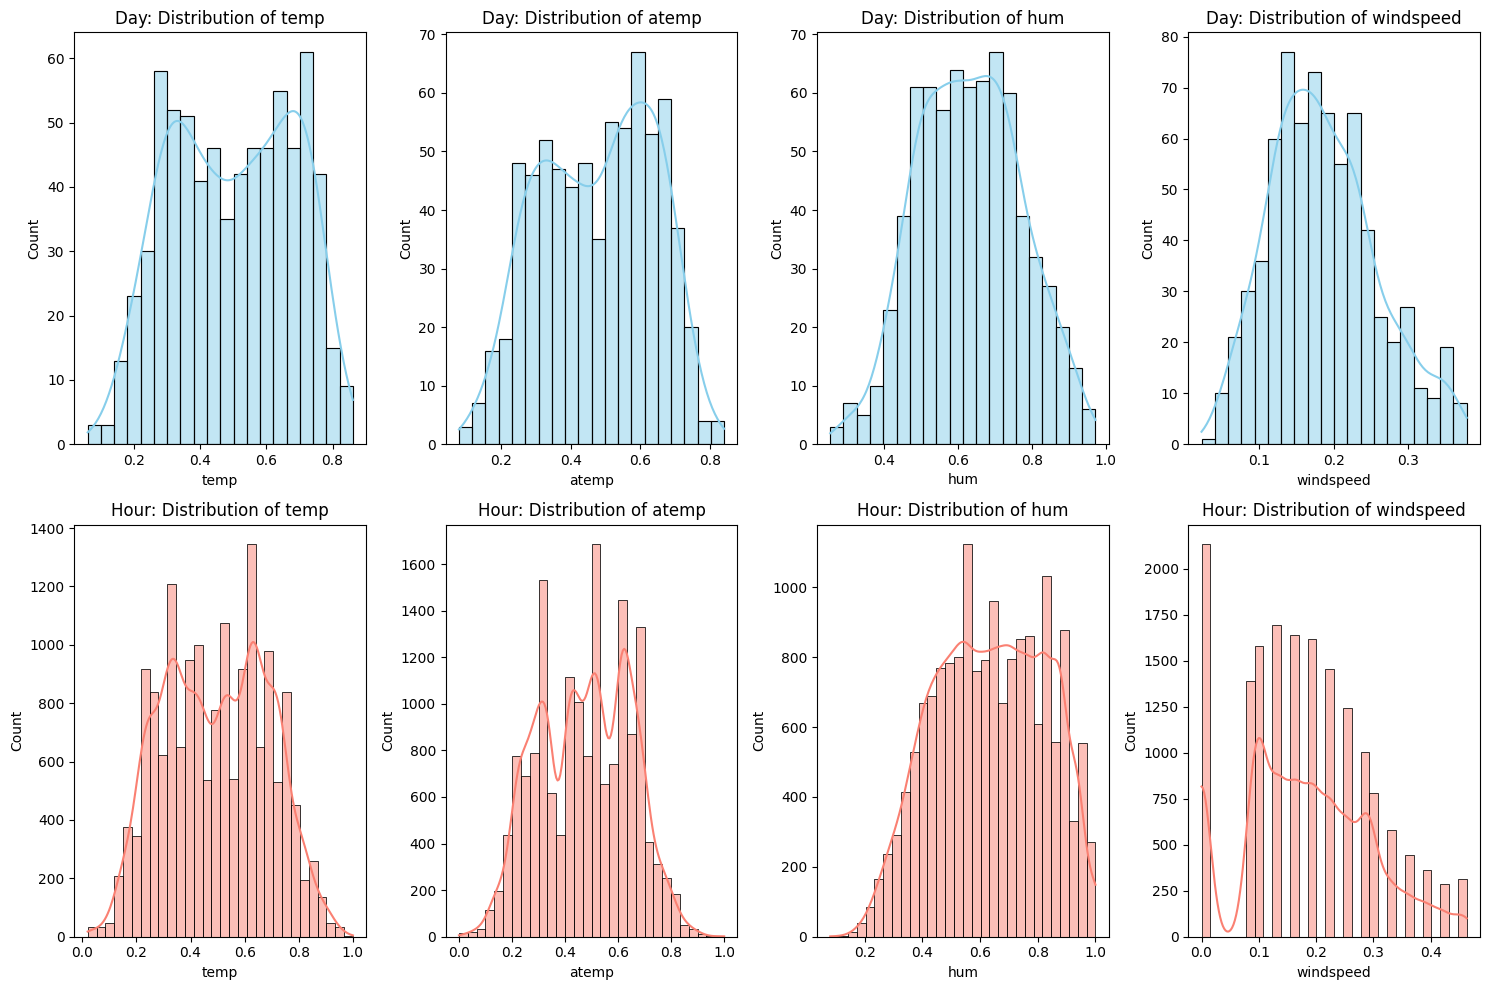

In [4]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols[:-1]): # Exclude 'cnt'
    plt.subplot(2, 4, i + 1)
    sns.histplot(dfd[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Day: Distribution of {col}')

    plt.subplot(2, 4, i + 5)
    sns.histplot(dfh[col], kde=True, bins=30, color='salmon')
    plt.title(f'Hour: Distribution of {col}')

plt.tight_layout()
plt.show()


In [5]:

X = dfd.drop('cnt', axis=1)
y = dfd['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_h = dfh.drop('cnt', axis=1)
y_h = dfh['cnt']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)


In [6]:

param_grid_rf = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 15],      
    'min_samples_split': [2, 5]    
}

print("\n--- Starting Day-Wise Random Forest Hyperparameter Tuning ---")

grid_search_day = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3, 
    scoring='neg_mean_squared_error', 
    verbose=0,
    n_jobs=-1
)
grid_search_day.fit(X_train, y_train)
rf_day_tuned = grid_search_day.best_estimator_

print(f"\nDay-Wise Best Parameters: {grid_search_day.best_params_}")
print(f"Day-Wise Best CV Score (Negative MSE): {grid_search_day.best_score_}")




--- Starting Day-Wise Random Forest Hyperparameter Tuning ---

Day-Wise Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Day-Wise Best CV Score (Negative MSE): -1508925.0711812598


In [7]:

print("\n--- Starting Hour-Wise Random Forest Hyperparameter Tuning ---")

grid_search_hour = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=0, 
    n_jobs=-1
)

grid_search_hour.fit(X_train_h, y_train_h)
rf_hour_tuned = grid_search_hour.best_estimator_

print(f"\nHour-Wise Best Parameters: {grid_search_hour.best_params_}")
print(f"Hour-Wise Best CV Score (Negative MSE): {grid_search_hour.best_score_}")



--- Starting Hour-Wise Random Forest Hyperparameter Tuning ---

Hour-Wise Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Hour-Wise Best CV Score (Negative MSE): -3650.3133168447293


In [8]:

pred_rf_day = rf_day_tuned.predict(X_test)
pred_rf_hour = rf_hour_tuned.predict(X_test_h)

lr_day = LinearRegression()
lr_day.fit(X_train, y_train)
pred_lr_day = lr_day.predict(X_test)

lr_hour = LinearRegression()
lr_hour.fit(X_train_h, y_train_h)
pred_lr_hour = lr_hour.predict(X_test_h)

print("\nModels Trained (Random Forest Tuned).")



Models Trained (Random Forest Tuned).


In [9]:
def evaluate_model(y_true, y_pred, model_name):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {model_name} Performance ---")
    print(f"  Test R-squared (Test Accuracy Metric): {r2:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    return r2


train_r2_rf_day = rf_day_tuned.score(X_train, y_train)
train_r2_rf_hour = rf_hour_tuned.score(X_train_h, y_train_h)

print("\n==============================================")
print("       Tuned Model Evaluation Results         ")
print("==============================================")

r2_rf_day_tuned = evaluate_model(y_test, pred_rf_day, "DAY-WISE Random Forest (Tuned)")
r2_lr_day = evaluate_model(y_test, pred_lr_day, "DAY-WISE Linear Regression")

r2_rf_hour_tuned = evaluate_model(y_test_h, pred_rf_hour, "HOUR-WISE Random Forest (Tuned)")
r2_lr_hour = evaluate_model(y_test_h, pred_lr_hour, "HOUR-WISE Linear Regression")




       Tuned Model Evaluation Results         

--- DAY-WISE Random Forest (Tuned) Performance ---
  Test R-squared (Test Accuracy Metric): 0.6527
  Mean Squared Error (MSE): 1308161.82
  Root Mean Squared Error (RMSE): 1143.75
  Mean Absolute Error (MAE): 970.51

--- DAY-WISE Linear Regression Performance ---
  Test R-squared (Test Accuracy Metric): 0.5712
  Mean Squared Error (MSE): 1615096.62
  Root Mean Squared Error (RMSE): 1270.86
  Mean Absolute Error (MAE): 1075.67

--- HOUR-WISE Random Forest (Tuned) Performance ---
  Test R-squared (Test Accuracy Metric): 0.8612
  Mean Squared Error (MSE): 3333.10
  Root Mean Squared Error (RMSE): 57.73
  Mean Absolute Error (MAE): 39.04

--- HOUR-WISE Linear Regression Performance ---
  Test R-squared (Test Accuracy Metric): 0.3454
  Mean Squared Error (MSE): 15717.51
  Root Mean Squared Error (RMSE): 125.37
  Mean Absolute Error (MAE): 95.04


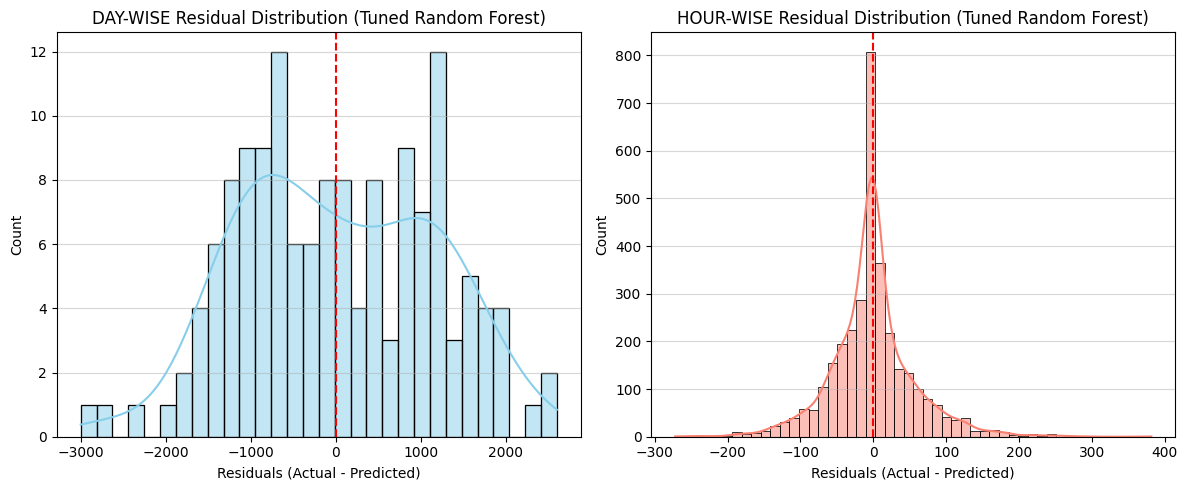

In [10]:
residuals_rf_day = y_test - pred_rf_day
residuals_rf_hour = y_test_h - pred_rf_hour

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_rf_day, kde=True, bins=30, color='skyblue')
plt.title("DAY-WISE Residual Distribution (Tuned Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.subplot(1, 2, 2)
sns.histplot(residuals_rf_hour, kde=True, bins=50, color='salmon')
plt.title("HOUR-WISE Residual Distribution (Tuned Random Forest)")
plt.xlabel("Residuals (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--')
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()


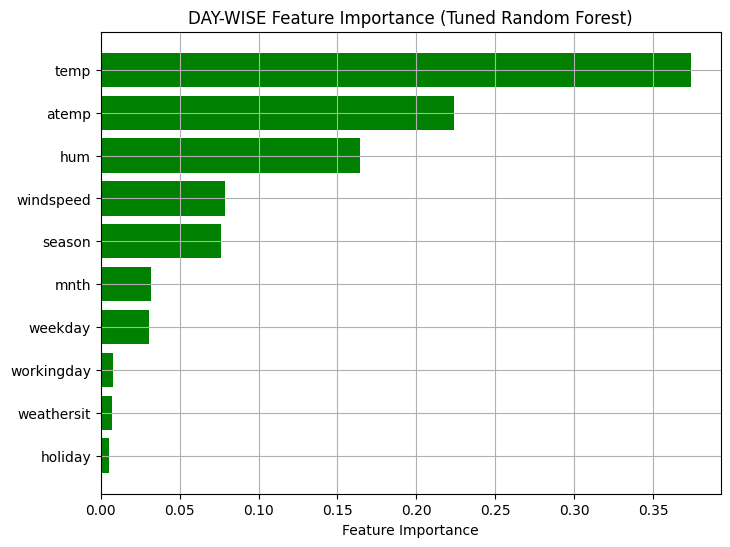

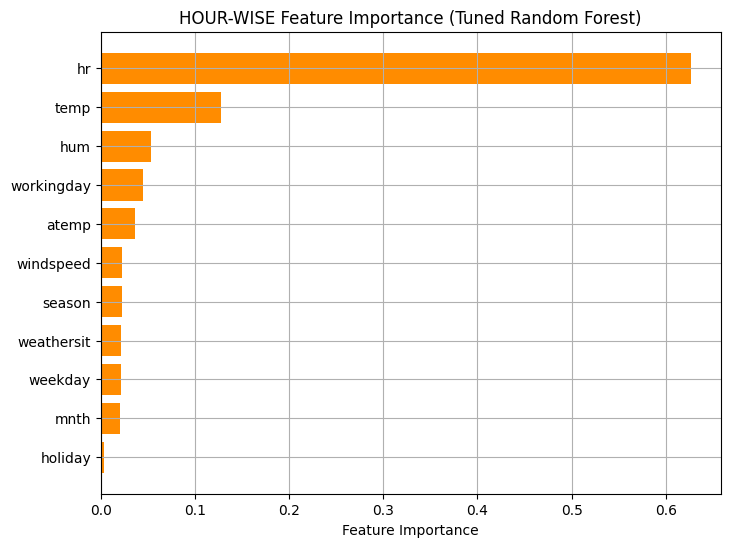

In [11]:

importances_day = rf_day_tuned.feature_importances_
feature_names_day = X.columns
fi_day = pd.DataFrame({'Feature': feature_names_day, 'Importance': importances_day}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_day['Feature'], fi_day['Importance'], color='green')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("DAY-WISE Feature Importance (Tuned Random Forest)")
plt.grid(True)
plt.show()

importances_hour = rf_hour_tuned.feature_importances_
feature_names_hour = X_h.columns
fi_hour = pd.DataFrame({'Feature': feature_names_hour, 'Importance': importances_hour}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(8,6))
plt.barh(fi_hour['Feature'], fi_hour['Importance'], color='darkorange')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("HOUR-WISE Feature Importance (Tuned Random Forest)")
plt.grid(True)
plt.show()



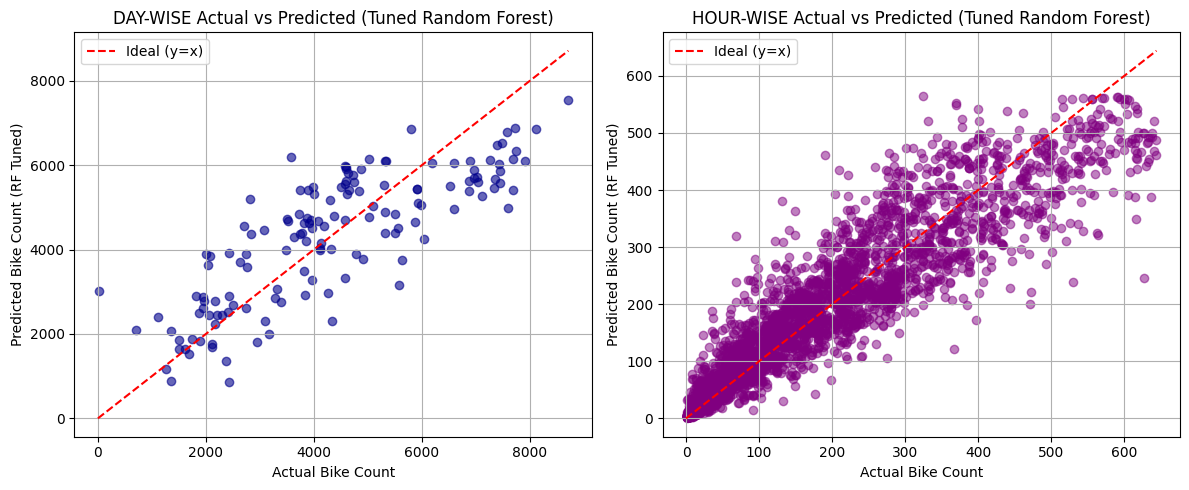

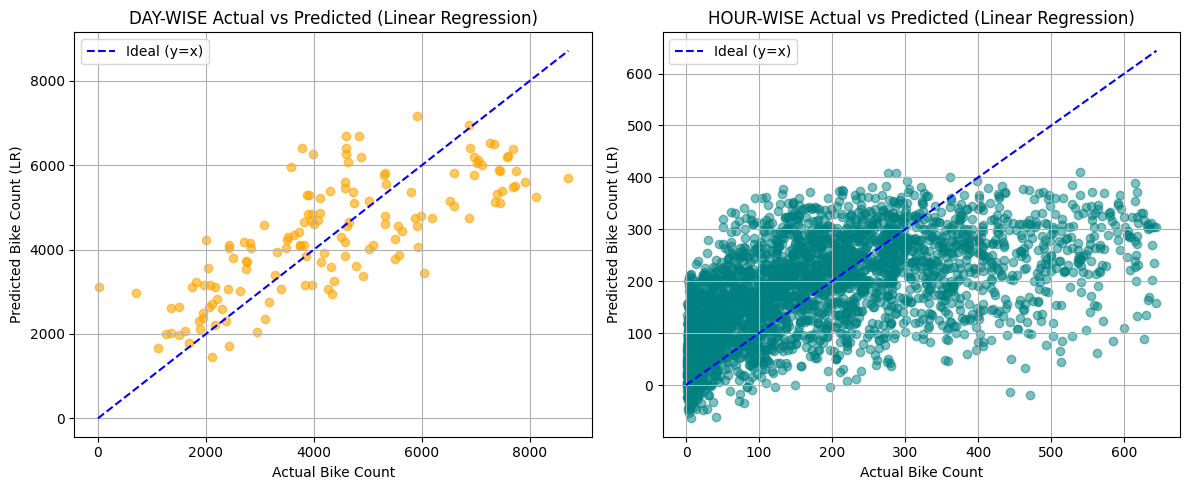

In [12]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_rf_day, alpha=0.6, color='darkblue')
max_val_day = max(y_test.max(), pred_rf_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'r--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF Tuned)")
plt.title("DAY-WISE Actual vs Predicted (Tuned Random Forest)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_rf_hour, alpha=0.5, color='purple')
max_val_hour = max(y_test_h.max(), pred_rf_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'r--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (RF Tuned)")
plt.title("HOUR-WISE Actual vs Predicted (Tuned Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test.values, pred_lr_day, alpha=0.6, color='orange')
max_val_day = max(y_test.max(), pred_lr_day.max())
plt.plot([0, max_val_day], [0, max_val_day], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("DAY-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_h.values, pred_lr_hour, alpha=0.5, color='teal')
max_val_hour = max(y_test_h.max(), pred_lr_hour.max())
plt.plot([0, max_val_hour], [0, max_val_hour], 'b--', label='Ideal (y=x)')
plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count (LR)")
plt.title("HOUR-WISE Actual vs Predicted (Linear Regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
print("\n\nAnalysis of Train Accuracy, Test Accuracy, and Model Performance is complete.")

print(f"\n[R-squared Values for Analysis]")
print(f"Day-Wise Random Forest: Train R2={train_r2_rf_day:.4f}, Test R2={r2_rf_day_tuned:.4f}")
print(f"Hour-Wise Random Forest: Train R2={train_r2_rf_hour:.4f}, Test R2={r2_rf_hour_tuned:.4f}")





Analysis of Train Accuracy, Test Accuracy, and Model Performance is complete.

[R-squared Values for Analysis]
Day-Wise Random Forest: Train R2=0.8910, Test R2=0.6527
Hour-Wise Random Forest: Train R2=0.9549, Test R2=0.8612


In [18]:
def create_lagged_features(df, target_col='cnt', lags=6, time_unit='day'):
    """Creates lagged features (for the previous 'lags' time steps) for time series forecasting."""
    df_ts = df.copy()
    for i in range(1, lags + 1):
        df_ts[f'{target_col}lag{i}'] = df_ts[target_col].shift(i)
    df_ts.dropna(inplace=True)
    return df_ts

def multi_step_forecast(model, last_X_row, steps=6):
    """
    Performs a recursive multi-step forecast (Forecast horizon: 6).
    Uses NumPy array manipulation to avoid Pandas indexing errors.
    """
    forecast = []
    

    current_features_array = last_X_row.values.copy() 

    num_features = len(current_features_array)
    
    lag_start_index = num_features - steps
    
    for step in range(1, steps + 1):

        next_prediction = model.predict(current_features_array.reshape(1, -1))[0]
        forecast.append(next_prediction)
   
        current_features_array[lag_start_index + 1 : num_features] = \
            current_features_array[lag_start_index : num_features - 1]
        
        current_features_array[lag_start_index] = next_prediction

    return forecast





    


In [15]:

dfd_ts = create_lagged_features(dfd, target_col='cnt', lags=6, time_unit='day')

X_ts_d = dfd_ts.drop('cnt', axis=1) 
y_ts_d = dfd_ts['cnt']

split_point = int(len(X_ts_d) * 0.8)
X_train_ts_d = X_ts_d.iloc[:split_point]
X_test_ts_d = X_ts_d.iloc[split_point:]
y_train_ts_d = y_ts_d.iloc[:split_point]
y_test_ts_d = y_ts_d.iloc[split_point:]

rf_day_ts = RandomForestRegressor(**grid_search_day.best_params_, random_state=42)
rf_day_ts.fit(X_train_ts_d, y_train_ts_d)

last_X_d = X_ts_d.iloc[-1] 

day_forecast = multi_step_forecast(rf_day_ts, last_X_d, steps=6)

print("\n--- Day-Wise (Next 6 Days) Forecast ---")
for i, pred in enumerate(day_forecast):
    print(f"Day + {i+1}: {int(round(pred))} bike rentals")




--- Day-Wise (Next 6 Days) Forecast ---
Day + 1: 1720 bike rentals
Day + 2: 1901 bike rentals
Day + 3: 1883 bike rentals
Day + 4: 1949 bike rentals
Day + 5: 1862 bike rentals
Day + 6: 1910 bike rentals


C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packag

In [16]:

dfh_ts = create_lagged_features(dfh, target_col='cnt', lags=6, time_unit='hour')


X_ts_h = dfh_ts.drop('cnt', axis=1)
y_ts_h = dfh_ts['cnt']

split_point = int(len(X_ts_h) * 0.8)
X_train_ts_h = X_ts_h.iloc[:split_point]
X_test_ts_h = X_ts_h.iloc[split_point:]
y_train_ts_h = y_ts_h.iloc[:split_point]
y_test_ts_h = y_ts_h.iloc[split_point:]

rf_hour_ts = RandomForestRegressor(**grid_search_hour.best_params_, random_state=42)
rf_hour_ts.fit(X_train_ts_h, y_train_ts_h)

last_X_h = X_ts_h.iloc[-1]

hour_forecast = multi_step_forecast(rf_hour_ts, last_X_h, steps=6)

print("\n--- Hour-Wise (Next 6 Hours) Forecast ---")
for i, pred in enumerate(hour_forecast):
    print(f"Hour + {i+1}: {int(round(pred))} bike rentals")

print("\nMulti-Step Forecasting Complete.")


--- Hour-Wise (Next 6 Hours) Forecast ---
Hour + 1: 37 bike rentals
Hour + 2: 27 bike rentals
Hour + 3: 22 bike rentals
Hour + 4: 20 bike rentals
Hour + 5: 19 bike rentals
Hour + 6: 27 bike rentals

Multi-Step Forecasting Complete.


C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rishy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packag